# Icosahedral Global Graph for Weather-Model-Graphs

This notebook demonstrates the complete pipeline:
1. Mesh generation (using @mandeepsingh2007's trimesh approach)
2. Grid-to-mesh connectivity (adapted from neural-lam's prob_model_global)
3. Full graph ready for neural-lam



In [24]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from weather_model_graphs.create.mesh.layouts.icosahedral import (
    create_icosahedral_mesh, connect_grid_to_mesh
)
from mpl_toolkits.mplot3d import Axes3D


In [25]:
def lat_lon_to_cartesian(lat, lon):
    """Convert lat/lon degrees to cartesian coordinates on unit sphere."""
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    
    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)
    
    return np.column_stack([x, y, z])

def cartesian_to_lat_lon(vertices):
    """Convert cartesian coordinates to lat/lon degrees."""
    x, y, z = vertices[:, 0], vertices[:, 1], vertices[:, 2]
    
    # Convert to spherical coordinates
    lon = np.degrees(np.arctan2(y, x))
    lat = np.degrees(np.arctan2(z, np.sqrt(x**2 + y**2)))
    
    return np.column_stack([lat, lon])

In [26]:
# Generate mesh hierarchy (Mandeep's approach)
mesh_levels = create_icosahedral_mesh(subdivisions=3)
vertices, faces = mesh_levels[-1]  # Finest level
print(f"Mesh nodes: {len(vertices)}")
print(f"Mesh faces: {len(faces)}")

Mesh nodes: 642
Mesh faces: 1280


In [27]:
# create dummy grid (e.g., 5deg resolution)
lats = np.arange(-90, 91, 5)
lons = np.arange(-180, 181, 5)
grid_lat, grid_lon = np.meshgrid(lats, lons, indexing='ij')
grid_lat_lon = np.column_stack([grid_lat.ravel(), grid_lon.ravel()])
print(f"Grid nodes: {len(grid_lat_lon)}")

Grid nodes: 2701


In [28]:
# Connect grid to mesh 
g2m_edges = connect_grid_to_mesh(grid_lat_lon, vertices, faces)
print(f"G2M edges: {g2m_edges.shape[1]}")

G2M edges: 4299


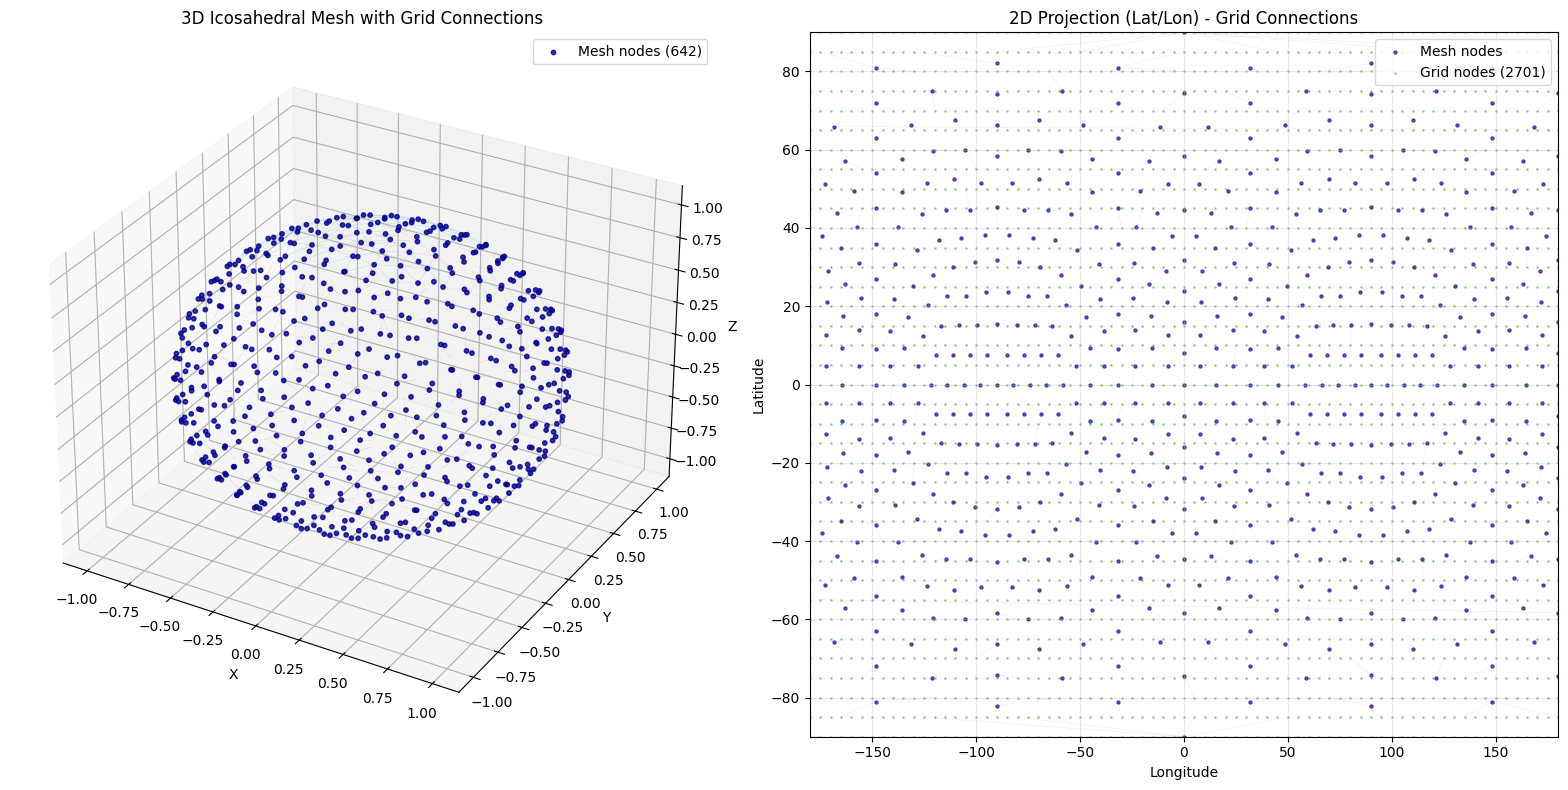


 Graph Statistics Summary:
Total mesh nodes: 642
Total grid nodes: 2701
G2M connections: 4299
Average connections per grid node: 1.59
Average connections per mesh node: 6.70


In [29]:
# Visualize Icosahedral Mesh with Grid Connections


fig = plt.figure(figsize=(16, 8))

# 3D Plot (left)
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_title("3D Icosahedral Mesh with Grid Connections", fontsize=12)

# Plot mesh edges (from faces)
for face in faces[:100]:  # Plot subset for clarity
    for i, j in [(0,1), (1,2), (2,0)]:
        ax1.plot3D(*zip(vertices[face[i]], vertices[face[j]]), 
                  color='lightblue', alpha=0.3, linewidth=0.5)

# Plot mesh nodes
ax1.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], 
           c='darkblue', s=10, label=f'Mesh nodes ({len(vertices)})', alpha=0.8)

# Plot sample of g2m connections (every 10th for clarity)
sample_step = 10
for i in range(0, g2m_edges.shape[1], sample_step):
    grid_idx, mesh_idx = g2m_edges[0, i], g2m_edges[1, i]
    
    # Convert grid point to cartesian for 3D plotting
    grid_lat, grid_lon = grid_lat_lon[grid_idx]
    grid_cart = lat_lon_to_cartesian(np.array([grid_lat]), np.array([grid_lon]))
    
    ax1.plot3D(*zip(grid_cart[0], vertices[mesh_idx]), 
              color='red', alpha=0.2, linewidth=0.3)

# Format 3D plot
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.legend(loc='upper right')

# 2D Plate Carree Projection (right)
ax2 = fig.add_subplot(122)
ax2.set_title("2D Projection (Lat/Lon) - Grid Connections", fontsize=12)

# Convert mesh vertices to lat/lon for 2D plotting
mesh_lat_lon = cartesian_to_lat_lon(vertices)

# Plot mesh nodes in 2D
ax2.scatter(mesh_lat_lon[:, 1], mesh_lat_lon[:, 0],  # lon, lat
           c='darkblue', s=5, label=f'Mesh nodes', alpha=0.6)

# Plot grid nodes
ax2.scatter(grid_lat_lon[:, 1], grid_lat_lon[:, 0],  # lon, lat
           c='green', s=1, label=f'Grid nodes ({len(grid_lat_lon)})', alpha=0.3)

# Plot sample of g2m connections
for i in range(0, g2m_edges.shape[1], sample_step*2):
    grid_idx, mesh_idx = g2m_edges[0, i], g2m_edges[1, i]
    
    grid_lon, grid_lat = grid_lat_lon[grid_idx, 1], grid_lat_lon[grid_idx, 0]
    mesh_lon, mesh_lat = mesh_lat_lon[mesh_idx, 1], mesh_lat_lon[mesh_idx, 0]
    
    ax2.plot([grid_lon, mesh_lon], [grid_lat, mesh_lat], 
            color='red', alpha=0.15, linewidth=0.3)

# Format 2D plot
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_xlim(-180, 180)
ax2.set_ylim(-90, 90)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Statistics summary
print("\n Graph Statistics Summary:")
print(f"Total mesh nodes: {len(vertices)}")
print(f"Total grid nodes: {len(grid_lat_lon)}")
print(f"G2M connections: {g2m_edges.shape[1]}")
print(f"Average connections per grid node: {g2m_edges.shape[1]/len(grid_lat_lon):.2f}")
print(f"Average connections per mesh node: {g2m_edges.shape[1]/len(vertices):.2f}")